# YouCook2 Temporal Generalization Experiment

**Goal:** Train on peak years (2013–2014), test on surrounding years to measure how temporal distance affects action recognition accuracy.

**Split design:**
```
2011 (val) | 2012 (test1) | [2013–2014 TRAIN] | 2015 (test2) | 2016 (test3)
```

## Step 0 — Imports & Install

In [38]:
!pip install torchcodec av --quiet

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models.video as video_models
import torchvision.transforms as transforms

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda

Mounted datasets:
['datasets']


---
## Step 1 — Load CSVs
Run this locally. Only needs your existing timestamp CSVs.

In [ ]:
df_tv = pd.read_csv('DatasetsWithTime/youcook2trainval_withtime.csv')
df_t  = pd.read_csv('DatasetsWithTime/youcook2test_withtime.csv')

if 'vid' in df_t.columns:
    df_t = df_t.rename(columns={'vid': 'Unnamed: 0'})

df = pd.concat([df_tv, df_t], ignore_index=True)
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

print(f'Total videos with timestamps: {len(df)}')
print(f'NaN timestamps dropped: {len(pd.concat([df_tv, df_t])) - len(df)}')
df['year'].value_counts().sort_index()

In [ ]:
grouped = df.groupby('year').size()
plt.figure(figsize=(12, 5))
bars = plt.bar(grouped.index, grouped.values, color='steelblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             int(yval), va='bottom', ha='center', fontsize=11)
plt.axvspan(2012.5, 2014.5, alpha=0.15, color='green', label='Training era')
plt.title('YouCook2 — Video Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Number of Videos')
plt.legend()
plt.tight_layout()
plt.savefig('year_distribution.png', dpi=150)
plt.show()

---
## Step 2 — Load Annotations and Create Temporal Splits

In [ ]:
def load_annotations(trainval_path='youcookii_annotations_trainval.json',
                     test_path=None):
    label_map = {}

    with open(trainval_path, 'r') as f:
        data = json.load(f)

    database = data.get('database', data)
    for vid_id, info in database.items():
        recipe_type = info.get('recipe_type', None)
        if recipe_type is not None:
            label_map[vid_id] = int(recipe_type)

    if test_path and os.path.exists(test_path):
        with open(test_path, 'r') as f:
            try:
                test_data = json.load(f)
                test_db   = test_data.get('database', test_data)
                for vid_id, info in test_db.items():
                    rt = info.get('recipe_type', None)
                    if rt is not None:
                        label_map[vid_id] = int(rt)
            except json.JSONDecodeError:
                f.seek(0)
                for line in f:
                    record = json.loads(line)
                    vid_id = record.get('id', record.get('video_id'))
                    rt     = record.get('recipe_type')
                    if vid_id and rt is not None:
                        label_map[vid_id] = int(rt)

    print(f'Videos with labels: {len(label_map)}')
    print(f'Unique classes:     {len(set(label_map.values()))}')
    return label_map


label_map = load_annotations(
    trainval_path='youcookii_annotations_trainval.json',
    test_path='youcookii_annotations_test_segments.json'
)

In [6]:
df['label'] = df['Unnamed: 0'].map(label_map)
before = len(df)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
print(f'Videos with matched labels: {len(df)} (dropped {before - len(df)} unmatched)')

train     = df[df['year'].isin([2013, 2014])].copy()
val       = df[df['year'] == 2011].copy()
test_2012 = df[df['year'] == 2012].copy()
test_2015 = df[df['year'] == 2015].copy()
test_2016 = df[df['year'] == 2016].copy()

splits = {
    'train':     train,
    'val':       val,
    'test_2012': test_2012,
    'test_2015': test_2015,
    'test_2016': test_2016,
}

print('\n── Split sizes ──')
for name, split in splits.items():
    print(f'{name:12s}: {len(split):4d} videos | classes: {split["label"].nunique()}')

NameError: name 'df' is not defined

In [7]:
train_classes = set(train['label'].unique())
print('── Class overlap with train ──')
for name in ['test_2012', 'test_2015', 'test_2016']:
    test_classes = set(splits[name]['label'].unique())
    overlap = len(train_classes & test_classes)
    pct = 100 * overlap / max(len(test_classes), 1)
    print(f'train ↔ {name}: {overlap}/{len(test_classes)} classes shared ({pct:.1f}%)')

NameError: name 'train' is not defined

In [8]:
os.makedirs('splits', exist_ok=True)
for name, split in splits.items():
    path = f'splits/{name}.csv'
    split.to_csv(path, index=False)
    print(f'Saved {path}')
#I have used kaggle to utilize gpu to complete further steps, just make sure your paths align where mentioned in the later steps.

NameError: name 'splits' is not defined

---
## Step 3 — Dataset Class

In [4]:
class YouCook2Dataset(Dataset):
    """
    Loads video clips using TorchCodec, samples num_frames evenly.
    Videos expected at: video_dir/{video_id}.mp4
    Corrupted videos return None and are filtered by collate_skip_none.
    """
    def __init__(self, df, video_dir, num_frames=16, transform=None):
        df = df[df['Unnamed: 0'].apply(
            lambda vid: os.path.exists(os.path.join(video_dir, f'{vid}.mp4'))
        )].reset_index(drop=True)

        self.df         = df
        self.video_dir  = video_dir
        self.num_frames = num_frames
        self.transform  = transform

        unique_labels  = sorted(df['label'].unique())
        self.label2idx = {l: i for i, l in enumerate(unique_labels)}
        self.idx2label = {i: l for l, i in self.label2idx.items()}

        print(f'Dataset ready: {len(self.df)} videos, {len(unique_labels)} classes')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        from torchcodec.decoders import VideoDecoder

        row      = self.df.iloc[idx]
        video_id = row['Unnamed: 0']
        label    = self.label2idx[row['label']]
        path     = os.path.join(self.video_dir, f'{video_id}.mp4')

        try:
            decoder = VideoDecoder(path)
            total   = len(decoder)

            # Clamp indices to valid range
            indices = list(np.linspace(0, max(total - 1, 0),
                                       self.num_frames, dtype=int))
            indices = [min(i, total - 1) for i in indices]  # safety clamp

            frames  = decoder.get_frames_at(indices=indices).data
            frames  = frames.float() / 255.0

            if self.transform:
                frames = torch.stack([
                    self.transform(frames[t])
                    for t in range(self.num_frames)
                ], dim=0)

            # [T, C, H, W] -> [C, T, H, W] for R3D-18
            frames = frames.permute(1, 0, 2, 3)
            return frames, label, video_id

        except Exception as e:
                return None 

---
## Step 4 — Model

In [16]:
# ── Update these paths to match your directories with videos and splits ── 
VIDEO_DIR  = '/kaggle/input/datasets/avanishgrampurohit/you-cook-2-actionrecognition-experiment/videos/videos/'
SPLITS_DIR = '/kaggle/input/datasets/avanishgrampurohit/you-cook-2-actionrecognition-experiment/splits/'

In [10]:
def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)
    
def build_model(num_classes):
    model = video_models.r3d_18(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
    return model


transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.Normalize(mean=[0.43216, 0.394666, 0.37645],
                         std= [0.22803,  0.22145,  0.216989])
])

BATCH_SIZE = 8

# Verify
print(f'Video files found: {len(os.listdir(VIDEO_DIR))}')

splits = {
    name: pd.read_csv(os.path.join(SPLITS_DIR, f'{name}.csv'))
    for name in ['train', 'val', 'test_2012', 'test_2015', 'test_2016']
}

train_dataset = YouCook2Dataset(splits['train'], VIDEO_DIR,
                                num_frames=16, transform=transform)
val_dataset   = YouCook2Dataset(splits['val'],   VIDEO_DIR,
                                num_frames=16, transform=transform)

# Note: collate_skip_none filters corrupted videos
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,
                          collate_fn=collate_skip_none)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          collate_fn=collate_skip_none)

num_classes = len(train_dataset.label2idx)
model       = build_model(num_classes).to(DEVICE)
print(f'Classes: {num_classes}')

Video files found: 1353


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/youcook2-temporal-splits/splits/train.csv'

In [11]:
import os
from torchcodec.decoders import VideoDecoder

# Check corruption rate across all files
files = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')]
small = [f for f in files if os.path.getsize(os.path.join(VIDEO_DIR, f)) < 500*1024]

print(f'Total files:     {len(files)}')
print(f'Likely corrupt:  {len(small)} (under 500KB)')
print(f'Likely valid:    {len(files) - len(small)}')
print(f'Corruption rate: {100*len(small)/len(files):.1f}%')

Total files:     1349
Likely corrupt:  55 (under 500KB)
Likely valid:    1294
Corruption rate: 4.1%


---
## Step 5 — Training

In [12]:
NUM_EPOCHS = 20
optimizer  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion  = nn.CrossEntropyLoss()

best_val_acc = 0.0
history      = defaultdict(list)

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for batch in train_loader:
        if batch is None:          # skip fully-corrupted batches
            continue
        frames, labels, _ = batch
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(frames)              # single forward pass
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * frames.size(0)
        preds       = outputs.argmax(dim=1)  # reuse outputs
        correct    += (preds == labels).sum().item()
        total      += frames.size(0)

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            if batch is None:
                continue
            frames, labels, _ = batch
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            preds       = model(frames).argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += frames.size(0)

    train_acc = correct     / max(total, 1)
    val_acc   = val_correct / max(val_total, 1)
    avg_loss  = train_loss  / max(total, 1)

    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {avg_loss:.4f} | '
          f'Train: {train_acc:.3f} | '
          f'Val(2011): {val_acc:.3f} | '
          f'Samples: {total}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        print(f'  ✓ Saved best model (val={val_acc:.3f})')

Epoch 01/20 | Loss: 5.0185 | Train: 0.014 | Val(2011): 0.006 | Samples: 718
  ✓ Saved best model (val=0.006)
Epoch 02/20 | Loss: 4.3465 | Train: 0.039 | Val(2011): 0.000 | Samples: 718
Epoch 03/20 | Loss: 3.9835 | Train: 0.095 | Val(2011): 0.006 | Samples: 718
Epoch 04/20 | Loss: 3.7472 | Train: 0.128 | Val(2011): 0.025 | Samples: 718
  ✓ Saved best model (val=0.025)
Epoch 05/20 | Loss: 3.4708 | Train: 0.182 | Val(2011): 0.013 | Samples: 718
Epoch 06/20 | Loss: 3.2417 | Train: 0.253 | Val(2011): 0.019 | Samples: 718
Epoch 07/20 | Loss: 3.0383 | Train: 0.291 | Val(2011): 0.019 | Samples: 718
Epoch 08/20 | Loss: 2.7422 | Train: 0.416 | Val(2011): 0.013 | Samples: 718
Epoch 09/20 | Loss: 2.6427 | Train: 0.499 | Val(2011): 0.019 | Samples: 718
Epoch 10/20 | Loss: 2.6611 | Train: 0.504 | Val(2011): 0.013 | Samples: 718
Epoch 11/20 | Loss: 2.6030 | Train: 0.529 | Val(2011): 0.013 | Samples: 718
Epoch 12/20 | Loss: 2.6268 | Train: 0.501 | Val(2011): 0.006 | Samples: 718
Epoch 13/20 | Loss: 2.

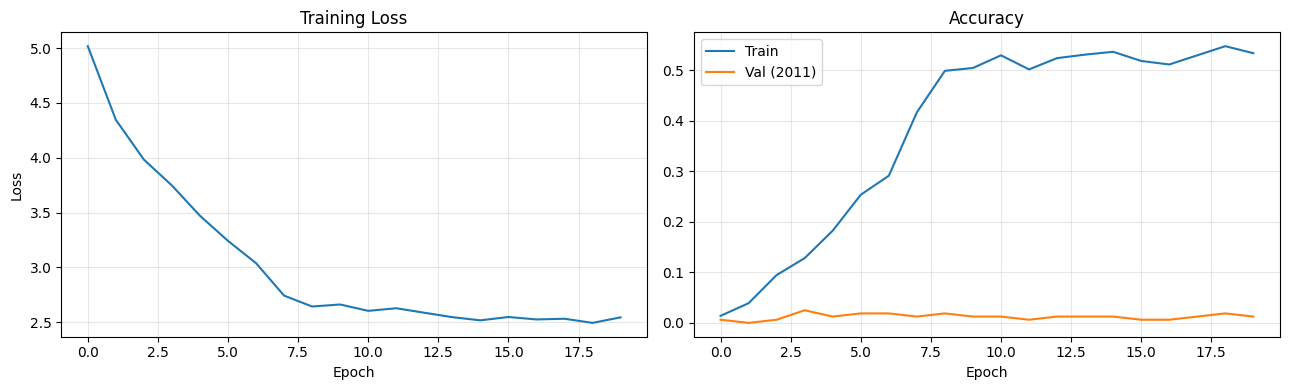

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val (2011)')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

---
## Step 6 — Evaluate All Temporal Splits

In [22]:
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()

def evaluate_split(df_split, split_name):
    dataset = YouCook2Dataset(df_split, VIDEO_DIR,
                              num_frames=16, transform=transform)
    if len(dataset) == 0:
        print(f'{split_name}: no videos found on disk')
        return None

    loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2,
                         collate_fn=collate_skip_none)
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            frames, labels, _ = batch
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            preds   = model(frames).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += frames.size(0)

    acc = correct / max(total, 1)
    print(f'{split_name:12s}: {acc:.3f} ({correct}/{total} correct)')
    return acc


print('── Temporal Generalization Results ──')
results = {}
for name in ['val', 'test_2012', 'test_2015', 'test_2016']:
    results[name] = evaluate_split(splits[name], name)

results['train'] = evaluate_split(splits['train'], 'train (in-dist)')

── Temporal Generalization Results ──
Dataset ready: 168 videos, 75 classes
val         : 0.025 (4/160 correct)
Dataset ready: 226 videos, 84 classes
test_2012   : 0.014 (3/212 correct)
Dataset ready: 167 videos, 74 classes
test_2015   : 0.006 (1/161 correct)
Dataset ready: 45 videos, 19 classes
test_2016   : 0.000 (0/43 correct)
Dataset ready: 743 videos, 89 classes
train (in-dist): 0.383 (275/718 correct)


---
## Step 7 — Results Plot (Paper Figure)

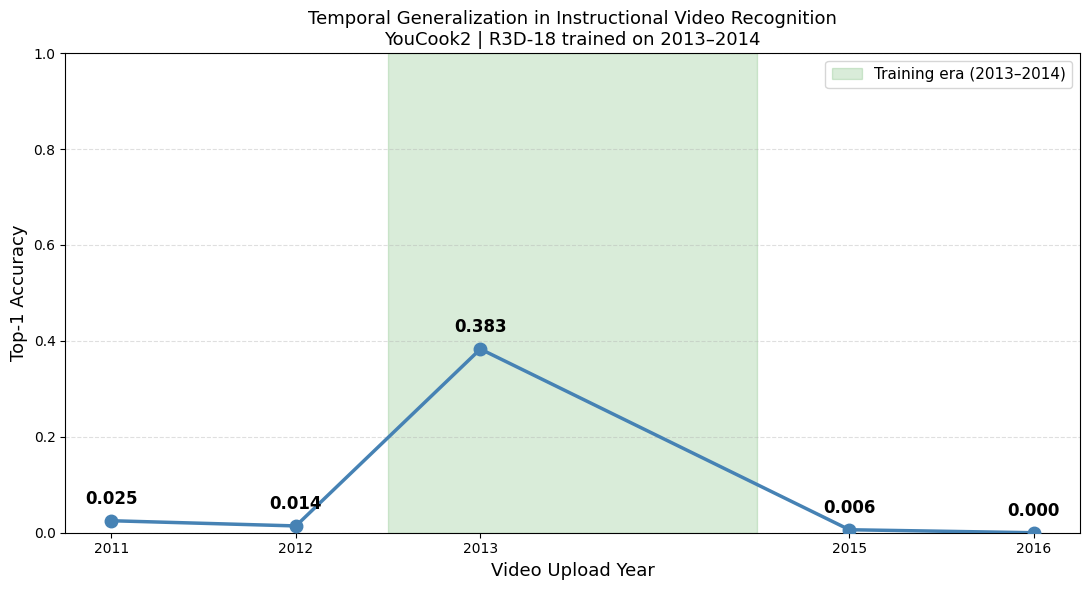

In [23]:
year_map = {
    'val':       2011,
    'test_2012': 2012,
    'train':     2013,
    'test_2015': 2015,
    'test_2016': 2016,
}

pairs = sorted(
    [(year_map[k], v) for k, v in results.items() if v is not None]
)
years, accs = zip(*pairs)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(years, accs, 'o-', linewidth=2.5,
        markersize=9, color='steelblue', zorder=3)
ax.axvspan(2012.5, 2014.5, alpha=0.15, color='green',
           label='Training era (2013–2014)')

for y, a in zip(years, accs):
    ax.annotate(f'{a:.3f}', (y, a),
                textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Video Upload Year', fontsize=13)
ax.set_ylabel('Top-1 Accuracy', fontsize=13)
ax.set_title(
    'Temporal Generalization in Instructional Video Recognition\n'
    'YouCook2 | R3D-18 trained on 2013–2014',
    fontsize=13
)
ax.set_xticks(list(years))
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/temporal_generalization.png', dpi=150)
plt.show()

In [24]:
print(f'\n{"Split":<15} {"Year":<8} {"Accuracy":<12} {"Gap":<8} Direction')
print('-' * 52)
for name, acc in sorted(results.items(),
                         key=lambda x: year_map.get(x[0], 0)):
    if acc is None:
        continue
    year = year_map[name]
    gap  = abs(year - 2013)
    direction = 'in-dist' if name == 'train' else \
                'backward' if year < 2013 else 'forward'
    print(f'{name:<15} {year:<8} {acc:<12.3f} {gap:<8} {direction}')


Split           Year     Accuracy     Gap      Direction
----------------------------------------------------
val             2011     0.025        2        backward
test_2012       2012     0.014        1        backward
train           2013     0.383        0        in-dist
test_2015       2015     0.006        2        forward
test_2016       2016     0.000        3        forward


# **Testing For I3D**

## Repeating Steps 4-7

## I3D Model

In [21]:
!pip install pytorchvideo --quiet

def build_i3d(num_classes):
    model = torch.hub.load('facebookresearch/pytorchvideo',
                           'i3d_r50', pretrained=True)
    
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head
    in_features = model.blocks[6].proj.in_features
    model.blocks[6].proj = nn.Linear(in_features, num_classes)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
    return model

splits = {
    name: pd.read_csv(os.path.join(SPLITS_DIR, f'{name}.csv'))
    for name in ['train', 'val', 'test_2012', 'test_2015', 'test_2016']
}


NUM_FRAMES_I3D = 32

transform_i3d = transforms.Compose([
    transforms.Resize((224, 224)),  # ← I3D needs 224, not 112
    transforms.Normalize(mean=[0.43216, 0.394666, 0.37645],
                         std= [0.22803,  0.22145,  0.216989])
])

train_dataset_i3d = YouCook2Dataset(splits['train'], VIDEO_DIR,
                                    num_frames=NUM_FRAMES_I3D, transform=transform_i3d)
val_dataset_i3d   = YouCook2Dataset(splits['val'],   VIDEO_DIR,
                                    num_frames=NUM_FRAMES_I3D, transform=transform_i3d)

train_loader_i3d = DataLoader(train_dataset_i3d, batch_size=4,
                               shuffle=True,  num_workers=0,
                               collate_fn=collate_skip_none)
val_loader_i3d   = DataLoader(val_dataset_i3d,   batch_size=4,
                               shuffle=False, num_workers=0,
                               collate_fn=collate_skip_none)

num_classes_i3d = len(train_dataset_i3d.label2idx)
model_i3d       = build_i3d(num_classes_i3d).to(DEVICE)
print(f'Classes: {num_classes_i3d}')

Dataset ready: 743 videos, 89 classes
Dataset ready: 168 videos, 75 classes


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


Trainable params: 182,361 / 27,406,233 (0.7%)
Classes: 89


## Step 5 - Training I3D

In [23]:
NUM_EPOCHS    = 20
optimizer_i3d = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_i3d.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_i3d = torch.optim.lr_scheduler.StepLR(
    optimizer_i3d, step_size=7, gamma=0.1
)
criterion_i3d    = nn.CrossEntropyLoss()
best_val_acc_i3d = 0.0
history_i3d      = defaultdict(list)

for epoch in range(NUM_EPOCHS):
    model_i3d.train()
    train_loss, correct, total = 0.0, 0, 0

    for batch_idx, batch in enumerate(train_loader_i3d):
        if batch is None:
            continue
        frames, labels, _ = batch
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)

        optimizer_i3d.zero_grad()
        outputs = model_i3d(frames)
        loss    = criterion_i3d(outputs, labels)
        loss.backward()
        optimizer_i3d.step()

        train_loss += loss.item() * frames.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += frames.size(0)


    scheduler_i3d.step()

    model_i3d.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_loader_i3d:
            if batch is None:
                continue
            frames, labels, _ = batch
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            preds       = model_i3d(frames).argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += frames.size(0)

    train_acc = correct     / max(total, 1)
    val_acc   = val_correct / max(val_total, 1)
    avg_loss  = train_loss  / max(total, 1)

    history_i3d['train_loss'].append(avg_loss)
    history_i3d['train_acc'].append(train_acc)
    history_i3d['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {avg_loss:.4f} | '
          f'Train: {train_acc:.3f} | '
          f'Val(2011): {val_acc:.3f} | '
          f'Samples: {total}')

    if val_acc > best_val_acc_i3d:
        best_val_acc_i3d = val_acc
        torch.save(model_i3d.state_dict(), '/kaggle/working/best_i3d.pth')
        print(f'  ✓ Saved best I3D model (val={val_acc:.3f})')

Epoch 01/20 | Loss: 4.1101 | Train: 0.135 | Val(2011): 0.019 | Samples: 718
  ✓ Saved best I3D model (val=0.019)
Epoch 02/20 | Loss: 3.3324 | Train: 0.220 | Val(2011): 0.006 | Samples: 718
Epoch 03/20 | Loss: 2.9272 | Train: 0.323 | Val(2011): 0.000 | Samples: 718
Epoch 04/20 | Loss: 2.6629 | Train: 0.366 | Val(2011): 0.000 | Samples: 718
Epoch 05/20 | Loss: 2.3339 | Train: 0.471 | Val(2011): 0.000 | Samples: 718
Epoch 06/20 | Loss: 2.1109 | Train: 0.528 | Val(2011): 0.019 | Samples: 718
Epoch 07/20 | Loss: 1.8769 | Train: 0.609 | Val(2011): 0.000 | Samples: 718
Epoch 08/20 | Loss: 1.5392 | Train: 0.799 | Val(2011): 0.000 | Samples: 718
Epoch 09/20 | Loss: 1.4515 | Train: 0.847 | Val(2011): 0.006 | Samples: 718
Epoch 10/20 | Loss: 1.4254 | Train: 0.844 | Val(2011): 0.000 | Samples: 718
Epoch 11/20 | Loss: 1.3899 | Train: 0.840 | Val(2011): 0.000 | Samples: 718
Epoch 12/20 | Loss: 1.3899 | Train: 0.850 | Val(2011): 0.006 | Samples: 718
Epoch 13/20 | Loss: 1.3547 | Train: 0.859 | Val(201

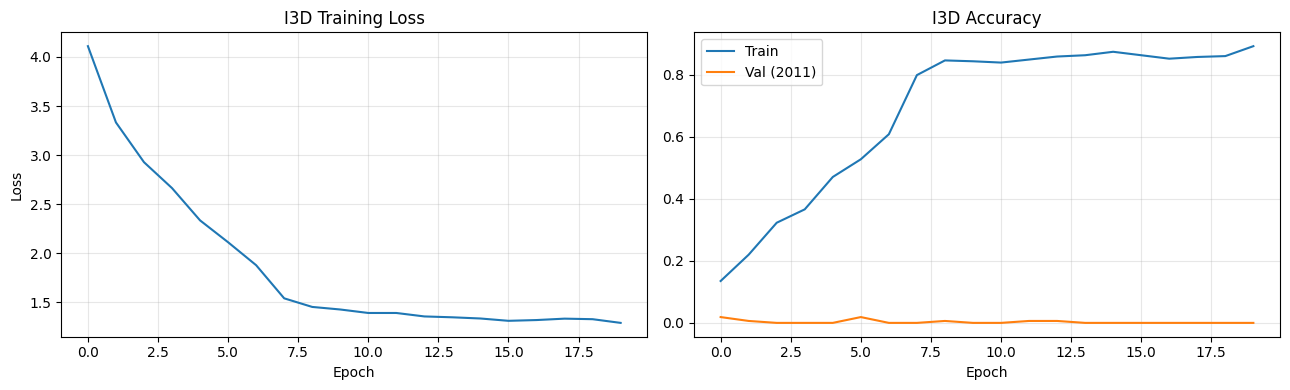

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_i3d['train_loss'])
ax1.set_title('I3D Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(history_i3d['train_acc'], label='Train')
ax2.plot(history_i3d['val_acc'],   label='Val (2011)')
ax2.set_title('I3D Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/i3d_training_curves.png', dpi=150)
plt.show()

## Step 6 - Evaluate All Temporal Splits - I3D


In [28]:
model_i3d.load_state_dict(torch.load('/kaggle/working/best_i3d.pth'))
model_i3d.eval()

def evaluate_split_i3d(df_split, split_name):
    dataset = YouCook2Dataset(df_split, VIDEO_DIR,
                              num_frames=NUM_FRAMES_I3D, transform=transform_i3d)
    if len(dataset) == 0:
        print(f'{split_name}: no videos found on disk')
        return None

    loader = DataLoader(dataset, batch_size=4,
                        shuffle=False, num_workers=0,
                        collate_fn=collate_skip_none)
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue
            frames, labels, _ = batch
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            preds   = model_i3d(frames).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += frames.size(0)

    acc = correct / max(total, 1)
    print(f'{split_name:12s}: {acc:.3f} ({correct}/{total} correct)')
    return acc


print('── I3D Temporal Generalization Results ──')
results_i3d = {}
for name in ['val', 'test_2012', 'test_2015', 'test_2016']:
    results_i3d[name] = evaluate_split_i3d(splits[name], name)

results_i3d['train'] = evaluate_split_i3d(splits['train'], 'train (in-dist)')

── I3D Temporal Generalization Results ──
Dataset ready: 168 videos, 75 classes
val         : 0.019 (3/160 correct)
Dataset ready: 226 videos, 84 classes
test_2012   : 0.028 (6/212 correct)
Dataset ready: 167 videos, 74 classes
test_2015   : 0.012 (2/161 correct)
Dataset ready: 45 videos, 19 classes
test_2016   : 0.023 (1/43 correct)
Dataset ready: 743 videos, 89 classes
train (in-dist): 0.277 (199/718 correct)


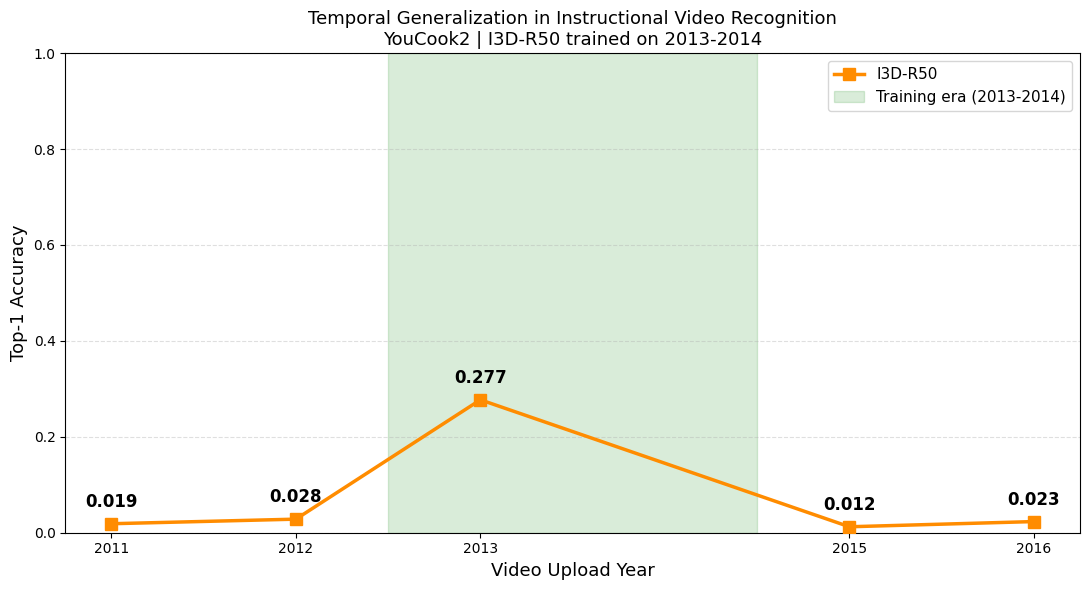


Split           Year     Accuracy     Direction
---------------------------------------------
val             2011     0.019        backward
test_2012       2012     0.028        backward
train           2013     0.277        in-dist
test_2015       2015     0.012        forward
test_2016       2016     0.023        forward


In [30]:
year_map = {
    'val':       2011,
    'test_2012': 2012,
    'train':     2013,
    'test_2015': 2015,
    'test_2016': 2016,
}

pairs_i3d = sorted([(year_map[k], v) for k, v in results_i3d.items() if v is not None])
years_i3d, accs_i3d = zip(*pairs_i3d)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(years_i3d, accs_i3d, 's-', label='I3D-R50',
        color='darkorange', linewidth=2.5, markersize=9, zorder=3)
ax.axvspan(2012.5, 2014.5, alpha=0.15, color='green',
           label='Training era (2013-2014)')

for y, a in zip(years_i3d, accs_i3d):
    ax.annotate(f'{a:.3f}', (y, a),
                textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Video Upload Year', fontsize=13)
ax.set_ylabel('Top-1 Accuracy', fontsize=13)
ax.set_title(
    'Temporal Generalization in Instructional Video Recognition\n'
    'YouCook2 | I3D-R50 trained on 2013-2014',
    fontsize=13
)
ax.set_xticks(list(years_i3d))
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/i3d_temporal_generalization.png', dpi=150)
plt.show()

# Summary table
print(f'\n{"Split":<15} {"Year":<8} {"Accuracy":<12} Direction')
print('-' * 45)
for name, acc in sorted(results_i3d.items(), key=lambda x: year_map.get(x[0], 0)):
    if acc is None:
        continue
    year      = year_map[name]
    direction = 'in-dist'  if name == 'train' else \
                'backward' if year < 2013     else 'forward'
    print(f'{name:<15} {year:<8} {acc:<12.3f} {direction}')